###  import the  libraries    

In [10]:
import pandas as pd
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt

shap.initjs()
print("Libraries loaded ✅")   

Libraries loaded ✅


###  load  the  data sets    


In [11]:
df = pd.read_csv("../../data/processed/churn_cleaned.csv")
model = joblib.load("../models/churn_model.pkl")

X = df.drop(columns=["Churn"])
y = df["Churn"]

print(f"Model: {type(model).__name__}")
print(f"Features: {X.shape[1]}")    

Model: RandomForestClassifier
Features: 33


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Test set: {X_test.shape[0]} customers")

Test set: 1409 customers


###  create sharp  explian   

In [13]:
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test)

# Handle both SHAP API versions:
# Older SHAP: list of arrays, one per class -> [array(n_samples, n_features), array(n_samples, n_features)]
# Newer SHAP: single array (n_samples, n_features, n_classes)
if isinstance(shap_values_raw, list):
    shap_values_churn = shap_values_raw[1]
    expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values_churn = shap_values_raw[:, :, 1]
    expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    shap_values_churn = shap_values_raw
    expected_value = explainer.expected_value

print(f"SHAP values shape: {shap_values_churn.shape}")
print(f"Expected value (base rate): {expected_value:.4f}")

SHAP values shape: (1409, 33)
Expected value (base rate): 0.4995


###  Global summary plot    

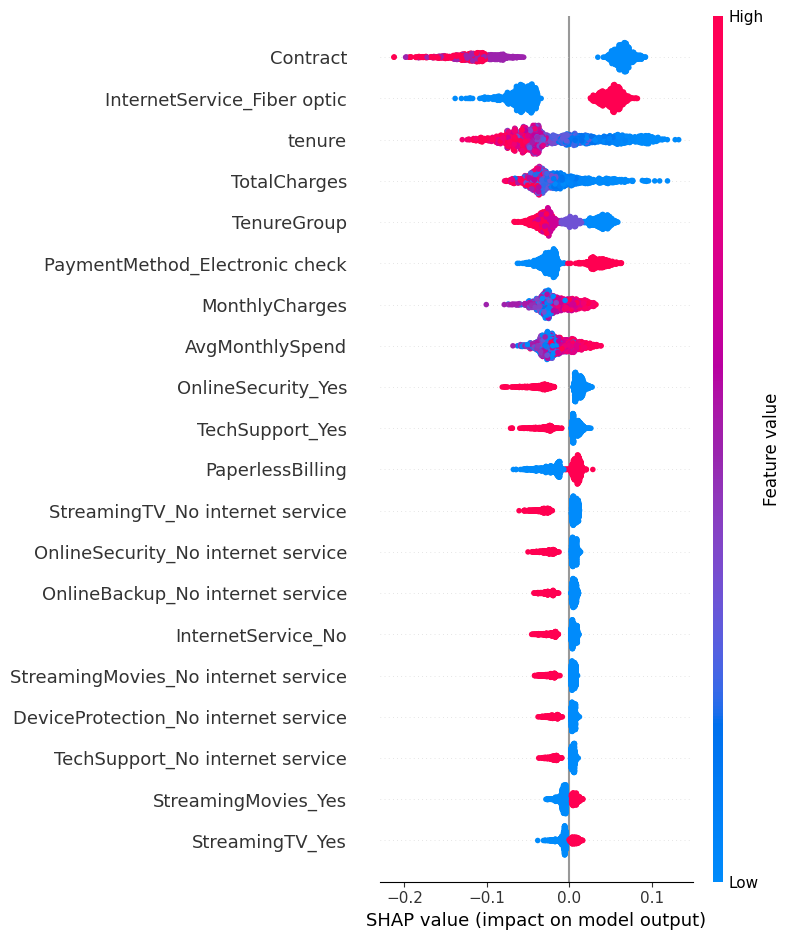

In [14]:
plt.figure()
shap.summary_plot(shap_values_churn, X_test, show=False)
plt.tight_layout()
plt.savefig("../outputs/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

###    Bar plot version    

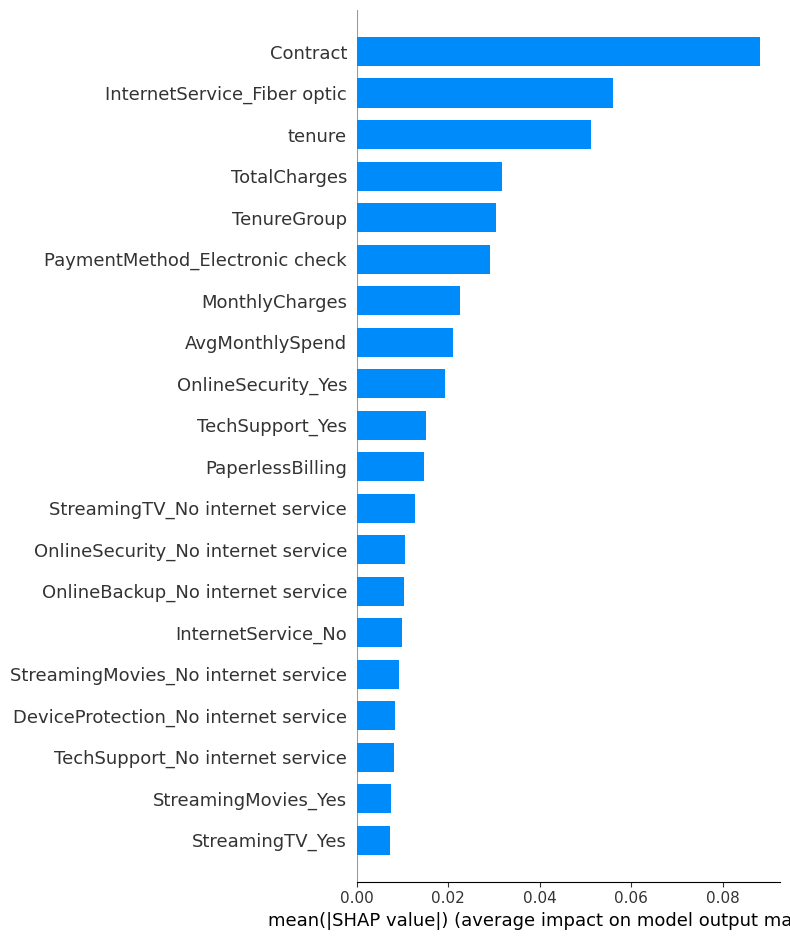

In [15]:
plt.figure()
shap.summary_plot(shap_values_churn, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../outputs/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

###  explain  single  customer    

Customer churn probability: 2.55%


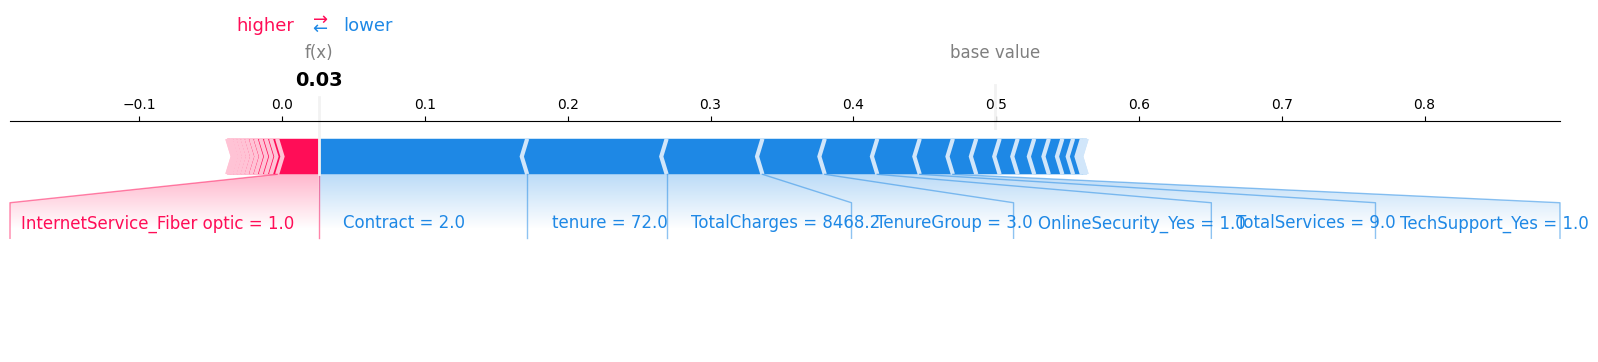

In [16]:
customer_idx = 0  # change this to inspect different customers
customer_data = X_test.iloc[[customer_idx]]
customer_shap = shap_values_churn[customer_idx]  # now correctly 1D (n_features,)

print(f"Customer churn probability: {model.predict_proba(customer_data)[0][1]:.2%}")

shap.force_plot(
    expected_value,
    customer_shap,
    customer_data,
    matplotlib=True,
    show=False
)
plt.savefig("../outputs/shap_force_example.png", dpi=150, bbox_inches="tight")
plt.show()   

### Function: get top N risk drivers for ANY customer    

In [17]:
def get_top_risk_factors(customer_idx, shap_values, X_data, top_n=3):
    """Returns the top N features driving this customer's churn risk, with direction."""
    customer_shap_vals = shap_values[customer_idx]
    feature_impact = pd.DataFrame({
        "Feature": X_data.columns,
        "SHAP_Value": customer_shap_vals,
        "Feature_Value": X_data.iloc[customer_idx].values
    })
    
    # Positive SHAP = pushes toward churn, negative = pushes toward staying
    feature_impact["Direction"] = feature_impact["SHAP_Value"].apply(
        lambda x: "increases risk" if x > 0 else "decreases risk"
    )
    feature_impact["AbsImpact"] = feature_impact["SHAP_Value"].abs()
    
    top_factors = feature_impact.sort_values("AbsImpact", ascending=False).head(top_n)
    return top_factors[["Feature", "Direction", "SHAP_Value", "Feature_Value"]]

# Test it
get_top_risk_factors(customer_idx=0, shap_values=shap_values_churn, X_data=X_test, top_n=5)

,Feature,Direction,SHAP_Value,Feature_Value
6,Contract,decreases risk,-0.146082,2.0
4,tenure,decreases risk,-0.097677,72.0
9,TotalCharges,decreases risk,-0.067078,8468.2
10,TenureGroup,decreases risk,-0.043652,3.0
19,OnlineSecurity_Yes,decreases risk,-0.036804,1.0


###  Generate top risk factors for ALL test customers   

In [18]:
all_customer_factors = []

for idx in range(len(X_test)):
    top_factors = get_top_risk_factors(idx, shap_values_churn, X_test, top_n=3)
    all_customer_factors.append({
        "customer_index": int(X_test.index[idx]),
        "churn_probability": float(model.predict_proba(X_test.iloc[[idx]])[0][1]),
        "top_risk_factors": top_factors.to_dict(orient="records")
    })

print(f"Generated explanations for {len(all_customer_factors)} customers ✅")
all_customer_factors[0]  # preview first one

Generated explanations for 1409 customers ✅


{'customer_index': 437,
 'churn_probability': 0.025517722792820566,
 'top_risk_factors': [{'Feature': 'Contract',
   'Direction': 'decreases risk',
   'SHAP_Value': -0.1460816572403241,
   'Feature_Value': 2.0},
  {'Feature': 'tenure',
   'Direction': 'decreases risk',
   'SHAP_Value': -0.09767723327304637,
   'Feature_Value': 72.0},
  {'Feature': 'TotalCharges',
   'Direction': 'decreases risk',
   'SHAP_Value': -0.0670784518139765,
   'Feature_Value': 8468.2}]}

### Save per-customer explanations     

In [19]:
with open("../outputs/customer_shap_explanations.json", "w") as f:
    json.dump(all_customer_factors, f, indent=2, default=str)

print("Saved customer-level SHAP explanations ✅")

Saved customer-level SHAP explanations ✅


### Dependence plot for top feature    

Top feature: Contract


<Figure size 640x480 with 0 Axes>

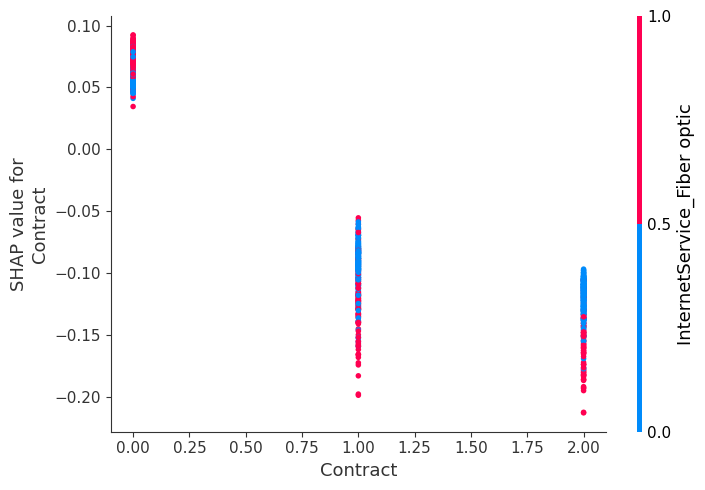

In [20]:
top_feature = X.columns[np.argsort(-np.abs(shap_values_churn).mean(axis=0))[0]]
print(f"Top feature: {top_feature}")

plt.figure()
shap.dependence_plot(top_feature, shap_values_churn, X_test, show=False)
plt.tight_layout()
plt.savefig("../outputs/shap_dependence_top_feature.png", dpi=150, bbox_inches="tight")
plt.show()

### Save the SHAP explainer itself 

In [ ]:
joblib.dump(explainer, "../models/shap_explainer.pkl")
print("SHAP explainer saved ")

SHAP explainer saved ✅


## Model Explainability (SHAP) Summary
- Used `TreeExplainer` (exact, fast for Random Forest) on the test set
- Global summary plot shows which features matter most across all customers, and in which direction
- Built `get_top_risk_factors()` — reusable function returning each customer's top N churn drivers with direction (increases/decreases risk)
- Generated and saved per-customer explanations for all test customers → `customer_shap_explanations.json`
- Saved the fitted `shap_explainer.pkl` — required so the FastAPI backend can explain **new** customers submitted via the prediction form, not just the test set
- This directly powers:
  - **Customer Detail page** — "why is this specific customer high risk"
  - **Retention Suggestions engine** — suggestions generated from each customer's actual top risk factors, not generic rules